In [33]:
import numpy as np
# np.random.seed(42)
from vpsto.vpsto import VPSTO, VPSTOOptions
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from shapely.geometry import Polygon, MultiPolygon, Point, MultiPoint, LineString

In [34]:
# Define some polygons for creating a collision environment
class CollisionEnvironment():
    def __init__(self):
        self.poly_list = []
        self.poly_list.append(np.array([[0.1, 0.13], [0.23, 0.12], [0.19, 0.28], [0.1, 0.32], [0.16, 0.2]]))
        self.poly_list.append(np.array([[0.25, 0.34], [0.31, 0.35], [0.32, 0.41], [0.27, 0.44], [0.23, 0.4]]))
        self.poly_list.append(np.array([[0.35, 0.12], [0.38, 0.1], [0.41, 0.11], [0.42, 0.21], [0.35, 0.24]]))
        self.multi_poly = MultiPolygon([Polygon(self.poly_list[0]), Polygon(self.poly_list[1]), Polygon(self.poly_list[2])])
        
    def getTrajDist(self, pts):
        return self.multi_poly.intersection(LineString(pts)).length

In [35]:
q_min = 0.0*np.ones(2)
q_max = 0.5*np.ones(2)
def loss_limits(candidates):
    q = candidates['pos']
    d_min = np.maximum(np.zeros_like(q), - q + q_min)
    d_max = np.maximum(np.zeros_like(q), q - q_max)
    return np.sum(d_min > 0.0, axis=(1,2)) + np.sum(d_max > 0.0, axis=(1,2))

env = CollisionEnvironment()
def loss_collision(candidates): 
    costs = []
    for traj in candidates['pos']:
        costs.append(env.getTrajDist(traj))
    costs = np.array(costs)
    costs += costs > 0.0
    return costs

def loss_curvature(candidates):
    dq = candidates['vel']
    ddq = candidates['acc']
    dq_sq = np.sum(dq**2, axis=-1)
    ddq_sq = np.sum(ddq**2, axis=-1)
    dq_ddq = np.sum(dq*ddq, axis=-1) 
    return np.mean((dq_sq * ddq_sq - dq_ddq**2) / (dq_sq**3 + 1e-6), axis=-1)

def loss(candidates):
    cost_curvature = loss_curvature(candidates)
    cost_collision = loss_collision(candidates)
    cost_limits = loss_limits(candidates)
    return candidates['T'] + 1e-3 * cost_curvature + 1e3 * cost_collision + 1e3 * cost_limits

In [36]:
opt = VPSTOOptions(ndof=2)
opt.vel_lim = np.array([0.1, 0.1])
# opt.vel_lim = np.array([0.5, 0.5])
opt.acc_lim = np.array([0.5, 0.5])
# opt.acc_lim = np.array([2.5, 2.5])
opt.N_via = 4
opt.N_eval = 100
opt.pop_size = 25
opt.max_iter = 200
opt.sigma_init = 1.5

traj_opt = VPSTO(opt)

In [37]:
q0 = np.array([0.1, 0.2]) # robot position
qd = np.array([0.4, 0.3])  # desired robot position
# qd = np.array([1.4, 1.3])  # desired robot position

In [38]:
sol = traj_opt.minimize(loss, q0, qT=qd, dqT=np.zeros_like(qd))

t_traj = np.linspace(0, sol.T_best, 1000)
pos, vel, acc = sol.get_posvelacc(t_traj)

print('Movement duration: ', sol.T_best)

VP-STO finished after 200 iterations with a final loss of 5.174603004374189
Movement duration:  5.153142907598188


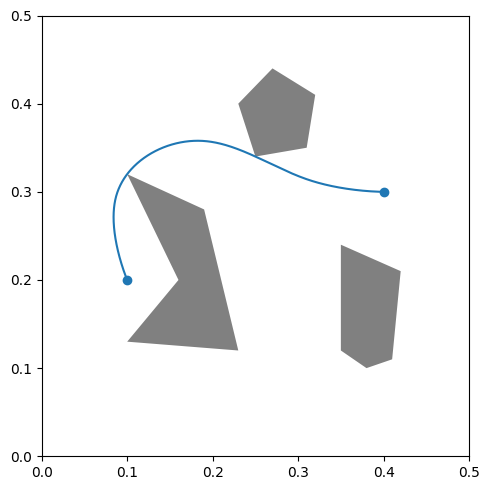

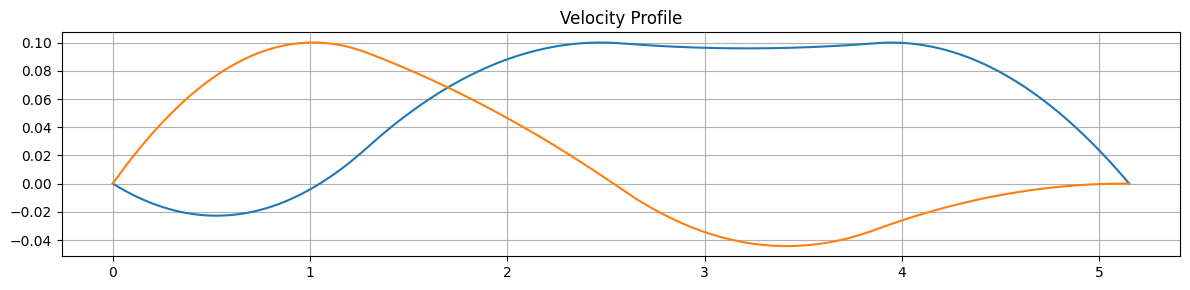

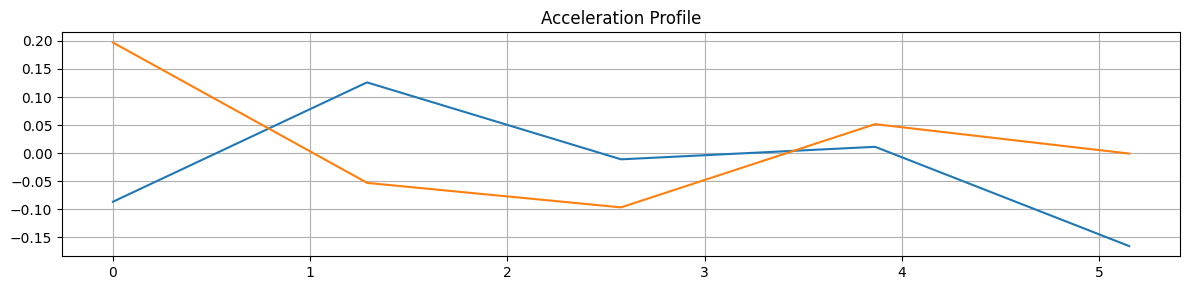

In [39]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.set_xlim([q_min[0], q_max[0]])
ax.set_ylim([q_min[1], q_max[1]])

ax.scatter([q0[0], qd[0]],[q0[1], qd[1]])
for pol in env.poly_list:
    ax.add_patch(patches.Polygon(pol, facecolor = 'gray'))

ax.plot(pos[:,0], pos[:,1])
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.grid()
plt.title('Velocity Profile')
plt.plot(t_traj, vel)
plt.tight_layout()

plt.figure(figsize=(12, 3))
plt.grid()
plt.title('Acceleration Profile')
plt.plot(t_traj, acc)
plt.tight_layout()

In [40]:
# import matplotlib.pyplot as plt
# import os

# # 确保 media 目录存在
# os.makedirs('media', exist_ok=True)

# # 保存图像的辅助函数
# def save_fig(path):
#     plt.gcf().set_size_inches(6, 6)
#     plt.tight_layout()
#     plt.savefig(path, dpi=200, bbox_inches='tight')
#     print(f"✅ 图像已保存: {path}")

# # 绘制静态障碍避障轨迹图
# fig, ax = plt.subplots(figsize=(6, 6))

# # 设置坐标范围
# ax.set_xlim([q_min[0], q_max[0]])
# ax.set_ylim([q_min[1], q_max[1]])

# # 绘制起点和终点
# ax.scatter([q0[0]], [q0[1]], c='green', s=100, marker='o', label='Start', zorder=5)
# ax.scatter([qd[0]], [qd[1]], c='red', s=100, marker='x', label='Goal', zorder=5)

# # 绘制障碍物
# for pol in env.poly_list:
#     ax.add_patch(patches.Polygon(pol, facecolor='gray', alpha=0.7, edgecolor='black'))

# # 绘制优化后的轨迹（使用 pos 变量而不是 q）
# ax.plot(pos[:,0], pos[:,1], 'r-', lw=3, label='VP-STO Trajectory', zorder=4)

# # 设置图像属性
# ax.set_xlabel('X Position')
# ax.set_ylabel('Y Position')
# ax.set_title('VP-STO Static Obstacle Avoidance')
# ax.legend()
# ax.grid(True, alpha=0.3)
# ax.set_aspect('equal')

# # 保存图像
# plt.tight_layout()
# plt.savefig('media/exp_static_obstacles_traj.png', dpi=200, bbox_inches='tight')
# print(f"✅ 静态避障轨迹图已保存: media/exp_static_obstacles_traj.png")
# print(f"📈 轨迹持续时间: {sol.T_best:.2f}s")
# plt.show()

# # 同时保存速度和加速度剖面图（额外bonus）
# plt.figure(figsize=(10, 6))

# # 速度剖面
# plt.subplot(2, 1, 1)
# plt.plot(t_traj, vel[:, 0], 'b-', label='X Velocity')
# plt.plot(t_traj, vel[:, 1], 'r-', label='Y Velocity')
# plt.axhline(y=opt.vel_lim[0], color='b', linestyle='--', alpha=0.5, label='X Vel Limit')
# plt.axhline(y=opt.vel_lim[1], color='r', linestyle='--', alpha=0.5, label='Y Vel Limit')
# plt.axhline(y=-opt.vel_lim[0], color='b', linestyle='--', alpha=0.5)
# plt.axhline(y=-opt.vel_lim[1], color='r', linestyle='--', alpha=0.5)
# plt.ylabel('Velocity (m/s)')
# plt.title('Velocity Profile')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # 加速度剖面
# plt.subplot(2, 1, 2)
# plt.plot(t_traj, acc[:, 0], 'b-', label='X Acceleration')
# plt.plot(t_traj, acc[:, 1], 'r-', label='Y Acceleration')
# plt.axhline(y=opt.acc_lim[0], color='b', linestyle='--', alpha=0.5, label='X Acc Limit')
# plt.axhline(y=opt.acc_lim[1], color='r', linestyle='--', alpha=0.5, label='Y Acc Limit')
# plt.axhline(y=-opt.acc_lim[0], color='b', linestyle='--', alpha=0.5)
# plt.axhline(y=-opt.acc_lim[1], color='r', linestyle='--', alpha=0.5)
# plt.xlabel('Time (s)')
# plt.ylabel('Acceleration (m/s²)')
# plt.title('Acceleration Profile')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('media/exp_profiles_q_dq_ddq.png', dpi=200, bbox_inches='tight')
# print(f"✅ 速度/加速度剖面图已保存: media/exp_profiles_q_dq_ddq.png")
# plt.show()